# Visualization of detection and segmentation

In [ ]:
import os
import pandas as pd
from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
os.chdir('')

In [9]:
from shapescore import detection,maskgen,predict_survival,metrics
proj='example_viz'

In [10]:
detection.predict_bb(proj)

Detecting objects...


100%|██████████| 3/3 [00:07<00:00,  2.55s/it]


100%|██████████| 1/1 [00:00<00:00, 17.22it/s]


Saved visualization to project/example_viz/bbox_vis/1nphs_11hrhs_B01_Brightfield2and4ul_bbox.jpg


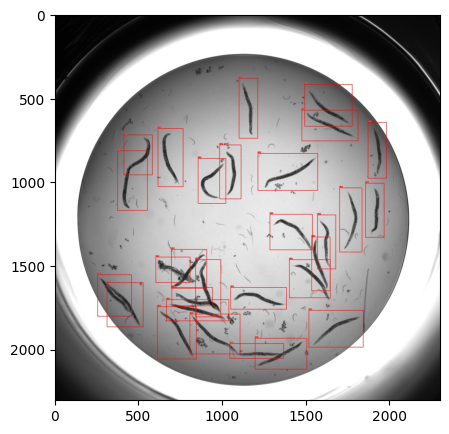

In [11]:
from shapescore.detection import visualize_predictions

bboxres=pd.read_csv('project/'+proj+'/bounding_boxes.csv')
os.makedirs('project/'+proj+'/bbox_vis',exist_ok=True)
for im in tqdm(os.listdir('project/'+proj+'/input_raw/')[:1]):
    df=bboxres[bboxres['filename']==im]
    visualize_predictions('project/'+proj+'/input_raw/'+im, results_df=df,output_path='project/'+proj+'/bbox_vis/'+im.replace('.jpg','_bbox.jpg'))

im=os.listdir('project/'+proj+'/input_raw/')[0]
img=Image.open('project/'+proj+'/bbox_vis/'+im.replace('.jpg','_bbox.jpg'))
image = np.array(img.convert("RGB"))

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('on')
plt.show()

In [12]:
maskgen.predict_segmentation(proj, batch_size=1,save_tiff=True)

Generating masks...


 75%|███████▌  | 3/4 [00:36<00:12, 12.30s/it]


In [13]:
from shapescore.utils import overlay_masks_on_image

for im in tqdm(os.listdir('project/'+proj+'/input_raw/')):
    overlay_masks_on_image('project/'+proj+'/input_raw/'+im, 'project/'+proj+'/processed_mask/mask_raw_uncropped/mask_raw_uncropped/'+im, 'project/'+proj+'/'+im.replace('.jpg','_confetti.jpg'))

 33%|███▎      | 1/3 [00:07<00:15,  7.77s/it]

Saved overlay image to: project/example_viz/1nphs_11hrhs_B01_Brightfield2and4ul_confetti.jpg


 67%|██████▋   | 2/3 [00:13<00:06,  6.53s/it]

Saved overlay image to: project/example_viz/1nphs_11hrhs_B02_Brightfield2and4ul_confetti.jpg


100%|██████████| 3/3 [00:22<00:00,  7.36s/it]

Saved overlay image to: project/example_viz/1nphs_11hrhs_B03_Brightfield2and4ul_confetti.jpg


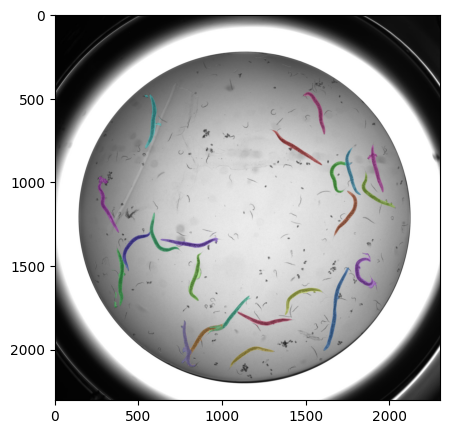

In [14]:
im='project/'+proj+'/1nphs_11hrhs_B02_Brightfield2and4ul_confetti.jpg'
image = np.array(Image.open(im).convert("RGB"))

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('on')
plt.show()